In [46]:
import sys
print(sys.executable)

c:\Users\User\Documents\FraudShield\venv\Scripts\python.exe


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [49]:
df = pd.read_csv("C:/Users/User/Documents/FraudShield/data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [51]:
X = df.drop('Class', axis=1)
y = df['Class']

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
# RandomForestClassifier(
#     n_estimators=200,
#     class_weight="balanced",
#     random_state=42
# )

rf_model.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [56]:
# For classification metrics
y_pred = rf_model.predict(X_test_scaled)

# For ROC-AUC
y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

In [57]:
best_threshold = 0.30

In [58]:
import os

os.makedirs("../models", exist_ok=True)

In [59]:
import joblib
joblib.dump(rf_model, "../models/fraud_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(best_threshold, "../models/threshold.pkl")

['../models/threshold.pkl']

In [60]:
import os
os.listdir("../models")

['fraud_model.pkl', 'scaler.pkl', 'threshold.pkl']

In [61]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


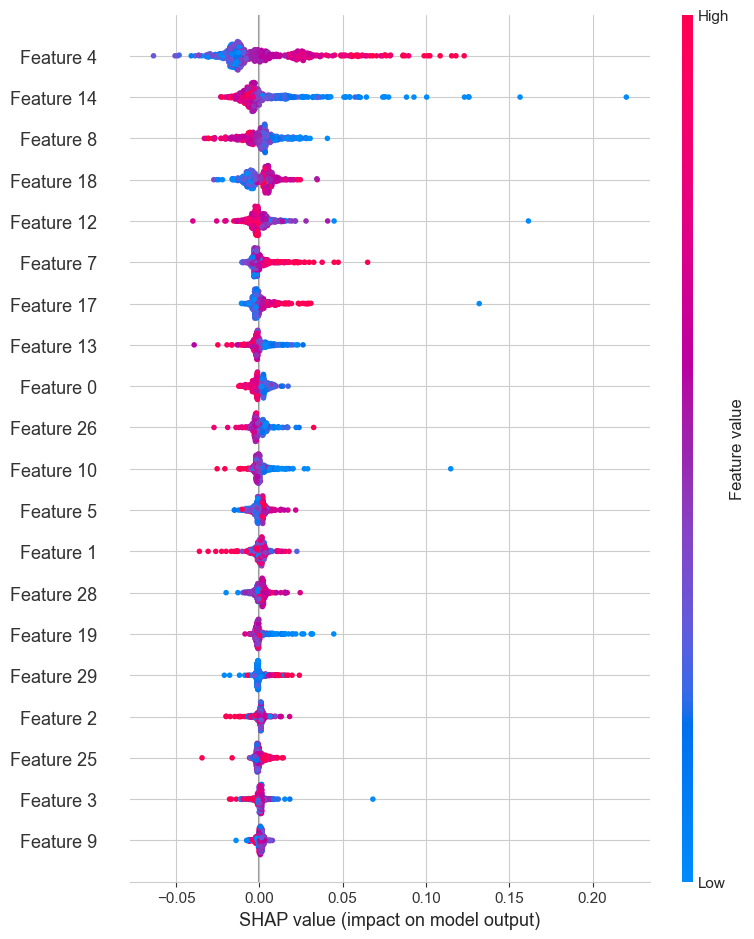

In [62]:
import shap

X_sample = X_test_scaled[:500]

explainer = shap.Explainer(rf_model, X_sample)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values[:, :, 1], X_sample)

In [63]:
print(type(shap_values))
print(len(shap_values) if isinstance(shap_values, list) else "Not a list")
print(shap_values.shape if hasattr(shap_values, 'shape') else "No shape")

<class 'shap._explanation.Explanation'>
Not a list
(500, 30, 2)


In [64]:
X.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')

In [65]:
import pandas as pd

X_sample = pd.DataFrame(X_test_scaled[:500], columns=X.columns)

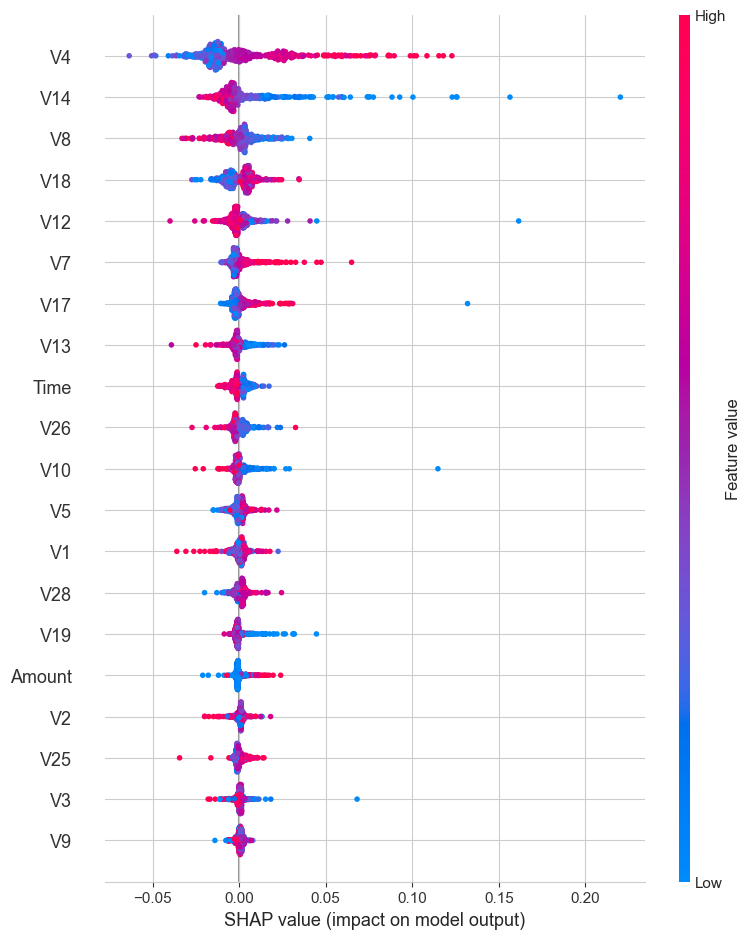

In [66]:
explainer = shap.Explainer(rf_model, X_sample)
shap_values = explainer(X_sample)

shap.summary_plot(shap_values[:, :, 1], X_sample)

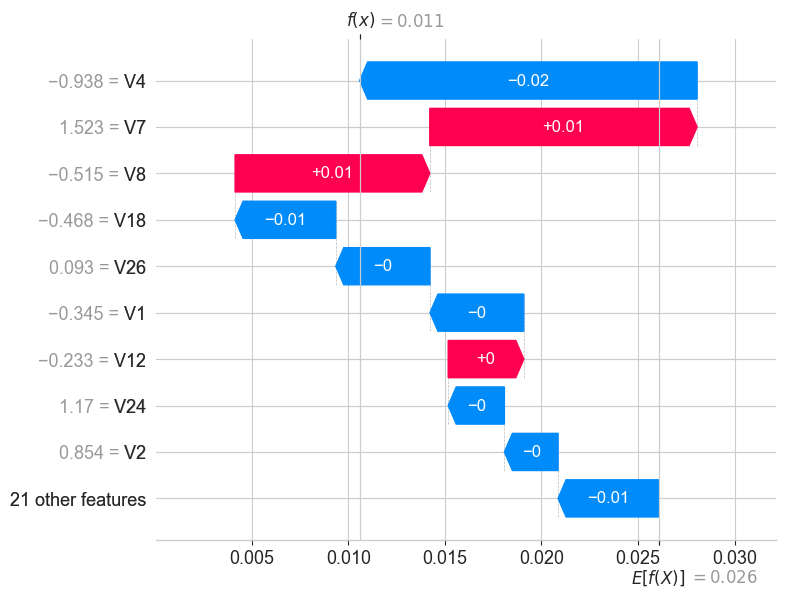

In [67]:
shap.plots.waterfall(shap_values[0, :, 1])

In [68]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
import streamlit as st

st.title("Credit Card Fraud Detection")

input_data = st.text_input("Enter transaction features")

if st.button("Predict"):
    # convert input
    prediction = rf_model.predict(...)
    st.write("Fraud" if prediction else "Not Fraud")

2026-03-22 12:46:01.331 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.331 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:46:01.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [70]:
import joblib

joblib.dump(rf_model, "model.pkl")

['model.pkl']

In [71]:
import os

os.makedirs("outputs", exist_ok=True)

In [72]:
from sklearn.metrics import classification_report
import json
import os

# Ensure folder exists
os.makedirs("outputs", exist_ok=True)

# Generate report
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Save
with open("outputs/metrics.json", "w") as f:
    json.dump(report_dict, f, indent=4)

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

In [75]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

c:\Users\User\Documents\FraudShield\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\User\Documents\FraudShield\venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [76]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [77]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9984024437344194
Precision: 0.5251798561151079
Recall: 0.7448979591836735
ROC-AUC: 0.9790517008716824


In [78]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.5, 0.7, 0.9]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}, Recall: {recall:.3f}")
    print("-"*40)

Threshold: 0.3
Precision: 0.116, Recall: 0.867
----------------------------------------
Threshold: 0.5
Precision: 0.525, Recall: 0.745
----------------------------------------
Threshold: 0.7
Precision: 0.768, Recall: 0.643
----------------------------------------
Threshold: 0.9
Precision: 0.955, Recall: 0.214
----------------------------------------


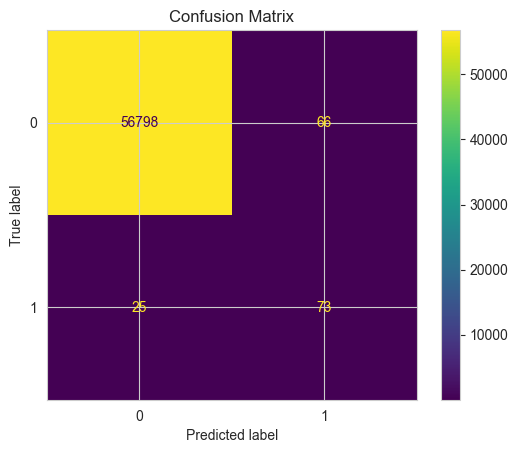

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.savefig("outputs/confusion_matrix.png")
plt.show()